## Simetría Esférica

Vamos a demostrar el poder de la Ley de Gauss deduciendo la ecuación fundamental que inició este curso: el campo eléctrico de una carga puntual.

Imagina una carga puntual $Q$ aislada en el espacio. Sabemos por simetría que su campo eléctrico "radia" hacia afuera en todas direcciones de manera perfectamente esférica. Por lo tanto, el campo $\vec{E}$ solo depende de la distancia $r$ a la carga.

**Elección de la Superficie Gaussiana:**
Para aprovechar esta simetría, encerramos nuestra carga puntual con una **esfera imaginaria** de radio $r$ centrada exactamente en $Q$. 


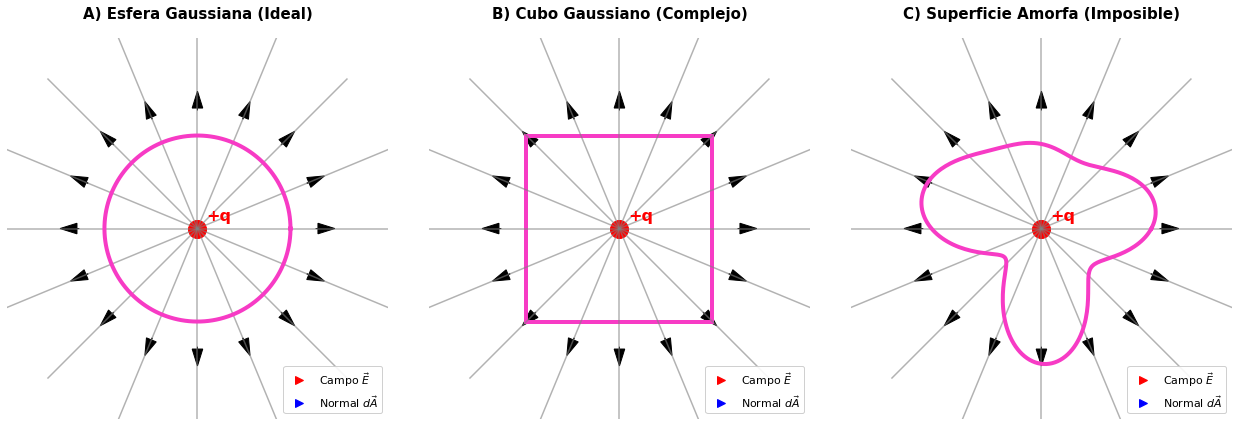

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Polygon
from IPython.display import HTML
import matplotlib.lines as mlines

# === NUEVO: AUMENTAR EL LÍMITE DE TAMAÑO DE LA ANIMACIÓN A 50 MB ===
plt.rcParams['animation.embed_limit'] = 50 

# === PARÁMETROS DE CONFIGURACIÓN ===
R_esfera_base = 2.2 
L_half_cube = 2.2 
N_field_lines = 16 
animation_frames = 150 # Un poco más lento para observar bien la papa

# === FUNCIÓN PARA CONFIGURAR LOS SUBPLOTS ===
def setup_subplot(ax, title):
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-4.5, 4.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=15, pad=20, fontweight='bold')
    
# === DIBUJAR LOS ELEMENTOS COMUNES Y LEYENDAS ===
def draw_physics_base(ax, charge_label):
    ax.plot(0, 0, 'ro', markersize=18)
    ax.text(0.2, 0.2, charge_label, color='red', fontsize=16, fontweight='bold')
    
    thetas_field = np.linspace(0, 2*np.pi, N_field_lines, endpoint=False)
    for theta in thetas_field:
        ax.plot([0, 5*np.cos(theta)], [0, 5*np.sin(theta)], 'gray', linewidth=1.5, alpha=0.6)
        arrow_dist = 2.8
        ax.arrow(arrow_dist*np.cos(theta), arrow_dist*np.sin(theta), 0.05*np.cos(theta), 0.05*np.sin(theta), 
                 head_width=0.25, head_length=0.4, fc='black', ec='black')
        
    leyenda_E = mlines.Line2D([], [], color='red', marker='>', markersize=8, linestyle='None', label=r'Campo $\vec{E}$')
    leyenda_dA = mlines.Line2D([], [], color='blue', marker='>', markersize=8, linestyle='None', label=r'Normal $d\vec{A}$')
    ax.legend(handles=[leyenda_E, leyenda_dA], loc='lower right', fontsize=11, framealpha=0.9)

# === CREAR LA FIGURA Y LOS 3 EJES ===
fig, (ax_sph, ax_cub, ax_pot) = plt.subplots(1, 3, figsize=(22, 7))
plt.subplots_adjust(wspace=0.1) 

setup_subplot(ax_sph, "A) Esfera Gaussiana (Ideal)")
setup_subplot(ax_cub, "B) Cubo Gaussiano (Complejo)")
setup_subplot(ax_pot, "C) Superficie Amorfa (Imposible)")

for ax in [ax_sph, ax_cub, ax_pot]:
    draw_physics_base(ax, '+q')

# === DIBUJAR LAS SUPERFICIES FIJAS ===
theta_surf = np.linspace(0, 2*np.pi, 300)

# 1. Esfera
x_esfera = R_esfera_base * np.cos(theta_surf)
y_esfera = R_esfera_base * np.sin(theta_surf)
ax_sph.plot(x_esfera, y_esfera, '#f73bc5', linewidth=4)

# 2. Cubo
cube_vertices = np.array([[-L_half_cube, -L_half_cube], [L_half_cube, -L_half_cube], 
                          [L_half_cube, L_half_cube], [-L_half_cube, L_half_cube], 
                          [-L_half_cube, -L_half_cube]])
ax_cub.add_patch(Polygon(cube_vertices, closed=True, fill=None, edgecolor='#f73bc5', linewidth=4))

# 3. Papa Amorfa (Ecuación polar)
r_papa_fija = 2.2 + 0.6*np.sin(3*theta_surf) + 0.4*np.cos(4*theta_surf) - 0.2*np.sin(2*theta_surf)
x_papa = r_papa_fija * np.cos(theta_surf)
y_papa = r_papa_fija * np.sin(theta_surf)
ax_pot.plot(x_papa, y_papa, '#f73bc5', linewidth=4)


# === ELEMENTOS DE LA ANIMACIÓN ===
probe_sph, = ax_sph.plot([], [], 'ko', markersize=12)
probe_cub, = ax_cub.plot([], [], 'ko', markersize=12)
probe_pot, = ax_pot.plot([], [], 'ko', markersize=12)

# Vectores (E y dA)
def crear_vectores(ax):
    return (ax.quiver([], [], [], [], color='red', scale=5, width=0.018),
            ax.quiver([], [], [], [], color='blue', scale=5, width=0.01))

E_sph, dA_sph = crear_vectores(ax_sph)
E_cub, dA_cub = crear_vectores(ax_cub)
E_pot, dA_pot = crear_vectores(ax_pot)

# Cuadros de información
# info_sph = ax_sph.text(-4.3, 3.2, '', fontsize=11, bbox=dict(facecolor='white', edgecolor='#f73bc5', alpha=0.9))
# info_cub = ax_cub.text(-4.3, 3.2, '', fontsize=11, bbox=dict(facecolor='white', edgecolor='#f73bc5', alpha=0.9))
# info_pot = ax_pot.text(-4.3, 3.2, '', fontsize=11, bbox=dict(facecolor='white', edgecolor='#f73bc5', alpha=0.9))

def init():
    probe_sph.set_data([], [])
    probe_cub.set_data([], [])
    probe_pot.set_data([], [])
    # info_sph.set_text('')
    # info_cub.set_text('')
    # info_pot.set_text('')
    return probe_sph, probe_cub, probe_pot#, info_sph, info_cub, info_pot

def animate(frame):
    p = frame / animation_frames 
    vec_len = 1.0 # Largo base de flechas
    
    # ================================
    # 1. ACTUALIZAR ESFERA
    # ================================
    phi = p * 2 * np.pi 
    px1, py1 = R_esfera_base * np.cos(phi), R_esfera_base * np.sin(phi)
    probe_sph.set_data([px1], [py1])
    
    E_dir1 = np.array([px1, py1]) / R_esfera_base
    dA_dir1 = np.array([px1, py1]) / R_esfera_base 
    
    E_sph.set_offsets([[px1, py1]]); E_sph.set_UVC([E_dir1[0]*vec_len], [E_dir1[1]*vec_len])
    dA_sph.set_offsets([[px1, py1]]); dA_sph.set_UVC([dA_dir1[0]*vec_len*0.8], [dA_dir1[1]*vec_len*0.8])
    
    #info_sph.set_text("ESFERA\n"
    #         r"$\bullet$ ¡$\vec{E} \parallel d\vec{A}$!" "\n"
    #         r"$\bullet$ $|E|$ es CONSTANTE" "\n"
    #         r"$\bullet$ Integral: $E \oint dA$")
    
    # ================================
    # 2. ACTUALIZAR CUBO
    # ================================
    perimeter = 8 * L_half_cube
    dist = p * perimeter
    
    dA_dir2 = np.array([0.0, 0.0]) 
    px2, py2 = 0.0, 0.0
    if dist < 2 * L_half_cube: 
        px2, py2 = L_half_cube, (dist - L_half_cube)
        dA_dir2 = np.array([1.0, 0.0])
    elif dist < 4 * L_half_cube: 
        px2, py2 = (3 * L_half_cube - dist), L_half_cube
        dA_dir2 = np.array([0.0, 1.0])
    elif dist < 6 * L_half_cube: 
        px2, py2 = -L_half_cube, (5 * L_half_cube - dist)
        dA_dir2 = np.array([-1.0, 0.0])
    else: 
        px2, py2 = (dist - 7 * L_half_cube), -L_half_cube
        dA_dir2 = np.array([0.0, -1.0])
        
    probe_cub.set_data([px2], [py2])
    
    r_probe_cub = np.sqrt(px2**2 + py2**2)
    E_dir2 = np.array([px2, py2]) / r_probe_cub
    
    E_cub.set_offsets([[px2, py2]]); E_cub.set_UVC([E_dir2[0]*vec_len], [E_dir2[1]*vec_len])
    dA_cub.set_offsets([[px2, py2]]); dA_cub.set_UVC([dA_dir2[0]*vec_len*0.8], [dA_dir2[1]*vec_len*0.8])
    
    #info_cub.set_text("CUBO\n"
    #         r"$\bullet$ Ángulo $\theta$ varía" "\n"
    #         r"$\bullet$ $|E|$ VARÍA (esquinas)" "\n"
    #         r"$\bullet$ Integral COMPLEJA")

    # ================================
    # 3. ACTUALIZAR PAPA AMORFA
    # ================================
    r_pot = 2.2 + 0.6*np.sin(3*phi) + 0.4*np.cos(4*phi) - 0.2*np.sin(2*phi)
    dr_dphi = 1.8*np.cos(3*phi) - 1.6*np.sin(4*phi) - 0.4*np.cos(2*phi)
    
    px3 = r_pot * np.cos(phi)
    py3 = r_pot * np.sin(phi)
    probe_pot.set_data([px3], [py3])
    
    r_probe_pot = np.sqrt(px3**2 + py3**2)
    E_dir3 = np.array([px3, py3]) / r_probe_pot
    
    dx_dphi = dr_dphi * np.cos(phi) - r_pot * np.sin(phi)
    dy_dphi = dr_dphi * np.sin(phi) + r_pot * np.cos(phi)
    dA_dir3_raw = np.array([dy_dphi, -dx_dphi])
    
    # Normalizamos con manejo de errores por si la magnitud es muy cercana a 0
    norm = np.linalg.norm(dA_dir3_raw)
    if norm > 1e-6:
        dA_dir3 = dA_dir3_raw / norm
    else:
        dA_dir3 = np.array([1.0, 0.0]) # Valor de respaldo seguro
    
    E_pot.set_offsets([[px3, py3]]); E_pot.set_UVC([E_dir3[0]*vec_len], [E_dir3[1]*vec_len])
    dA_pot.set_offsets([[px3, py3]]); dA_pot.set_UVC([dA_dir3[0]*vec_len*0.8], [dA_dir3[1]*vec_len*0.8])
    
    #info_pot.set_text("SUPERFICIE AMORFA\n"
    #         r"$\bullet$ Ángulo $\theta$ es CAÓTICO" "\n"
    #         r"$\bullet$ $|E|$ VARÍA salvajemente" "\n"
    #         r"$\bullet$ Integral IMPOSIBLE")
    
    return probe_sph, probe_cub, probe_pot#, info_sph, info_cub, info_pot

# === GENERAR Y MOSTRAR LA ANIMACIÓN ===
# anim = FuncAnimation(fig, animate, init_func=init, frames=animation_frames, interval=60, blit=True)
# plt.close() 
# HTML(anim.to_jshtml())

# === GENERAR Y GUARDAR LA ANIMACIÓN COMO GIF ===
# anim = FuncAnimation(fig, animate, init_func=init, frames=animation_frames, interval=60, blit=True)

# Guardar como GIF usando Pillow (ideal para GitHub y Jupyter Book)
# print("Generando GIF, por favor espera unos segundos...")
# anim.save('superficies_gaussianas.gif', writer='pillow', fps=15)
# print("¡GIF guardado con éxito como 'superficies_gaussianas.gif'!")

# plt.close() # Cierra la figura de matplotlib para no ensuciar el notebook

# Si quieres previsualizar el GIF dentro de tu notebook mientras editas:
# from IPython.display import Image
# Image(url='superficies_gaussianas.gif')


![Comparación de superficies gaussianas](images/superficies_gaussianas.gif)



**Análisis del Flujo:**
En la superficie de nuestra esfera imaginaria ocurren dos cosas vitales:
* El vector normal $d\vec{A}$ apunta radialmente hacia afuera en cada punto. Como el campo $\vec{E}$ también apunta radialmente hacia afuera, ambos vectores son paralelos ($\theta = 0^\circ$). Por tanto, el producto punto se simplifica: $\vec{E} \cdot d\vec{A} = E \, dA$.
* Todos los puntos de la esfera están a la misma distancia $r$ de la carga. Por simetría, la magnitud del campo $E$ debe ser constante en toda la superficie. 

**Planteamiento Matemático:**
Tomamos la Ley de Gauss y aplicamos nuestras simplificaciones:

$$\oint_{S} \vec{E} \cdot d\vec{A} = \frac{q_{\text{enc}}}{\epsilon_0}$$
$$\oint_{S} E \, dA = \frac{Q}{\epsilon_0}$$

Como $E$ es constante en nuestra esfera, ¡la sacamos de la integral!

$$E \oint_{S} dA = \frac{Q}{\epsilon_0}$$

¿Qué es $\oint dA$? Es simplemente el área total de nuestra superficie esférica. Sabiendo que el área de una esfera es $4\pi r^2$, sustituimos:

$$E (4\pi r^2) = \frac{Q}{\epsilon_0}$$

**Resultado Final:**
Despejamos $E$ y reorganizamos los términos:

$$E = \frac{1}{4\pi\epsilon_0} \frac{Q}{r^2}$$

¡Voilà! En apenas tres líneas de álgebra, hemos llegado exactamente a la misma ecuación empírica descubierta por Charles-Augustin de Coulomb. Sin integrales complejas, solo geometría y simetría.